In [28]:
!pip install --upgrade pandas pandas_datareader


In [29]:
import requests
import pandas as pd

API_KEY = "76e79bea0310025bde0ea382ae51ecb7cc4d561f"
ticker = "AAPL"
start = "2020-01-01"
end = "2025-11-01"

url = f"https://api.tiingo.com/tiingo/daily/{ticker}/prices"
params = {"startDate": start, "endDate": end, "token": API_KEY}

resp = requests.get(url, params=params)
resp.raise_for_status()               # raise if HTTP error
data = resp.json()

df = pd.DataFrame(data)               # Tiingo returns list of dicts
# If needed, set datetime index:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)
print(df.head())


                            close    high     low    open    volume  \
date                                                                  
2020-01-02 00:00:00+00:00  300.35  300.60  295.19  296.24  33911864   
2020-01-03 00:00:00+00:00  297.43  300.58  296.50  297.15  36633878   
2020-01-06 00:00:00+00:00  299.80  299.96  292.75  293.79  29644644   
2020-01-07 00:00:00+00:00  298.39  300.90  297.48  299.84  27877655   
2020-01-08 00:00:00+00:00  303.19  304.44  297.16  297.16  33090946   

                            adjClose    adjHigh     adjLow    adjOpen  \
date                                                                    
2020-01-02 00:00:00+00:00  72.339604  72.399817  71.096813  71.349706   
2020-01-03 00:00:00+00:00  71.636319  72.395000  71.412328  71.568881   
2020-01-06 00:00:00+00:00  72.207136  72.245672  70.509136  70.759621   
2020-01-07 00:00:00+00:00  71.867536  72.472072  71.648362  72.216770   
2020-01-08 00:00:00+00:00  73.023621  73.324685  71.571289  71.5

In [30]:
df.to_csv('AAPL.csv')

In [31]:
df=pd.read_csv('AAPL.csv')

In [32]:
df.head()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,2020-01-02 00:00:00+00:00,300.35,300.60,295.19,296.24,33911864,72.339604,72.399817,71.096813,71.349706,135647456,0.0,1.0
1,2020-01-03 00:00:00+00:00,297.43,300.58,296.50,297.15,36633878,71.636319,72.395000,71.412328,71.568881,146535512,0.0,1.0
2,2020-01-06 00:00:00+00:00,299.80,299.96,292.75,293.79,29644644,72.207136,72.245672,70.509136,70.759621,118578576,0.0,1.0
3,2020-01-07 00:00:00+00:00,298.39,300.90,297.48,299.84,27877655,71.867536,72.472072,71.648362,72.216770,111510620,0.0,1.0
4,2020-01-08 00:00:00+00:00,303.19,304.44,297.16,297.16,33090946,73.023621,73.324685,71.571289,71.571289,132363784,0.0,1.0


In [33]:
df.tail()

,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
1462,2025-10-27 00:00:00+00:00,268.81,269.12,264.6501,264.880,44888152,268.049557,268.358680,263.901425,264.130674,44888152,0.0,1.0
1463,2025-10-28 00:00:00+00:00,269.00,269.89,268.1500,268.985,41534759,268.239019,269.126501,267.391424,268.224062,41534759,0.0,1.0
1464,2025-10-29 00:00:00+00:00,269.70,271.41,267.1100,269.275,51086742,268.937039,270.642202,266.354366,268.513241,51086742,0.0,1.0
1465,2025-10-30 00:00:00+00:00,271.40,274.14,268.4800,271.990,69886534,270.632230,273.364479,267.720490,271.220561,69886534,0.0,1.0
1466,2025-10-31 00:00:00+00:00,270.37,277.32,269.1600,276.990,86167123,269.605144,276.535483,268.398567,276.206416,86167123,0.0,1.0


In [34]:
df1=df.reset_index()['close']

In [35]:
df1

0       300.35
1       297.43
2       299.80
3       298.39
4       303.19
         ...  
1462    268.81
1463    269.00
1464    269.70
1465    271.40
1466    270.37
Name: close, Length: 1467, dtype: float64

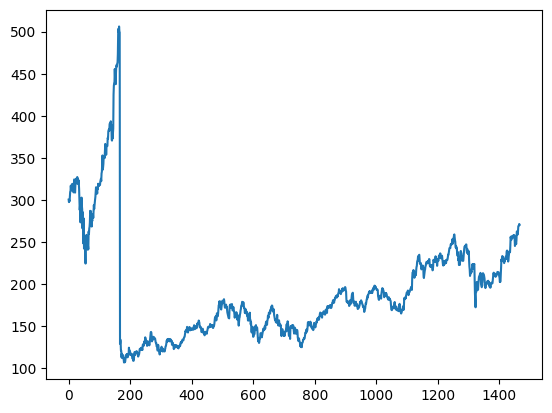

In [36]:
import matplotlib.pyplot as plt
plt.plot(df1)

In [37]:
### LSTM are sensitive to the scale of the data thus applying MinMax scaler
import numpy as np
df1

0       300.35
1       297.43
2       299.80
3       298.39
4       303.19
         ...  
1462    268.81
1463    269.00
1464    269.70
1465    271.40
1466    270.37
Name: close, Length: 1467, dtype: float64

In [38]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

In [39]:
print(df1)

[[0.48468378]
 [0.47737007]
 [0.4833062 ]
 ...
 [0.40791484]
 [0.41217282]
 [0.40959299]]


In [40]:
##splitting dataset into train and test split
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1),:1]

In [41]:
training_size,test_size

(953, 514)

In [42]:
train_data

array([[4.84683782e-01],
       [4.77370069e-01],
       [4.83306199e-01],
       [4.79774577e-01],
       [4.91797120e-01],
       [5.07927364e-01],
       [5.09680651e-01],
       [5.26286788e-01],
       [5.15566688e-01],
       [5.12210394e-01],
       [5.21978710e-01],
       [5.30720100e-01],
       [5.25309956e-01],
       [5.28140263e-01],
       [5.31972448e-01],
       [5.29668128e-01],
       [5.06224170e-01],
       [5.28115216e-01],
       [5.44771446e-01],
       [5.43594239e-01],
       [5.07626800e-01],
       [5.05497808e-01],
       [5.31020664e-01],
       [5.37532874e-01],
       [5.46950532e-01],
       [5.33976205e-01],
       [5.37783344e-01],
       [5.32924233e-01],
       [5.51934878e-01],
       [5.46098936e-01],
       [5.46299311e-01],
       [5.31396368e-01],
       [5.42968065e-01],
       [5.34652473e-01],
       [5.16493425e-01],
       [4.79248591e-01],
       [4.53951158e-01],
       [4.65397621e-01],
       [4.17482780e-01],
       [4.17082029e-01],


In [43]:
import numpy
# convert an array of values into a dataset matrix
def create_dataset(dataset, time_step=1):
	dataX, dataY = [], []
	for i in range(len(dataset)-time_step-1):
		a = dataset[i:(i+time_step), 0]   ###i=0, 0,1,2,3-----99   100
		dataX.append(a)
		dataY.append(dataset[i + time_step, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [44]:
# reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, ytest = create_dataset(test_data, time_step)

In [45]:
print(X_train.shape), print(y_train.shape)

(852, 100)
(852,)


(None, None)

In [46]:
print(X_test.shape), print(ytest.shape)

(413, 100)
(413,)


(None, None)

In [47]:
# reshape input to be [samples, time steps, features] which is required for LSTM
X_train =X_train.reshape(X_train.shape[0],X_train.shape[1] , 1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1] , 1)

In [48]:
### Create the Stacked LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [49]:
model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
model.fit(X_train,y_train,validation_data=(X_test,ytest),epochs=100,batch_size=64,verbose=1)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 385ms/step - loss: 0.0181 - val_loss: 0.0038
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - loss: 0.0076 - val_loss: 0.0013
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - loss: 0.0074 - val_loss: 8.1792e-04
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - loss: 0.0066 - val_loss: 6.5024e-04
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - loss: 0.0056 - val_loss: 4.6707e-04
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - loss: 0.0050 - val_loss: 7.5186e-04
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - loss: 0.0049 - val_loss: 7.9775e-04
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step - loss: 0.0044 - val_loss: 5.9078e-04
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 131ms/step - loss: 0.0050 - val_loss: 7.4664e-04
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - loss: 0.0041 - val_loss: 0.0015
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - loss: 0.0038 - val_loss: 4.4045e-04
Epoch 12

In [53]:
import tensorflow as tf

In [54]:
tf.__version__

'2.20.0'

In [55]:
### Lets Do the prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [56]:
##Transformback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

In [57]:
### Calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

180.87070344920795

In [58]:
### Test Data RMSE
math.sqrt(mean_squared_error(ytest,test_predict))

217.42071344350154

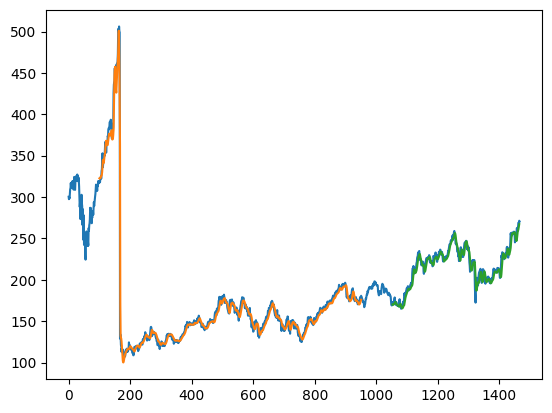

In [59]:
### Plotting
# shift train predictions for plotting
look_back=100
trainPredictPlot = numpy.empty_like(df1)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back, :] = train_predict
# shift test predictions for plotting
testPredictPlot = numpy.empty_like(df1)
testPredictPlot[:, :] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1, :] = test_predict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [60]:
len(test_data)

514

In [61]:
x_input=test_data[414:].reshape(1,-1)
x_input.shape

(1, 100)

In [62]:
temp_input=list(x_input)
temp_input=temp_input[0].tolist()

In [63]:
temp_input

[0.2302817783343769,
 0.2313337507827175,
 0.22444583594239192,
 0.22938008766437062,
 0.22241703193487783,
 0.22477144646211644,
 0.23584220413274887,
 0.23709455228553528,
 0.23408891671884785,
 0.2372448340638697,
 0.23584220413274887,
 0.23604257983719473,
 0.24628678772698803,
 0.2529242329367563,
 0.2644959298685034,
 0.26727614276768935,
 0.25825923606762674,
 0.25840951784596106,
 0.26123982467125856,
 0.26442078897933624,
 0.26128991859737,
 0.25492798998121474,
 0.25615529117094554,
 0.25878522229179707,
 0.2584345648090169,
 0.26134001252348155,
 0.2645961177207263,
 0.2694051346274264,
 0.2687789605510332,
 0.2678021289918597,
 0.2681026925485284,
 0.26852849092047587,
 0.261565435190983,
 0.2560050093926111,
 0.2522980588603631,
 0.23929868503443946,
 0.24172824045084523,
 0.24065122103944886,
 0.26652473387601744,
 0.2835065748278021,
 0.30685034439574194,
 0.30141515341264863,
 0.30760175328741385,
 0.3168190356919223,
 0.3154414527238572,
 0.3124608641202254,
 0.3107075

In [64]:
# demonstrate prediction for next 30 days
from numpy import array

lst_output=[]
n_steps=100
i=0
while(i<30):

    if(len(temp_input)>100):
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input = x_input.reshape((1, n_steps, 1))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps,1))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1


print(lst_output)

[0.4100442]
101
1 day input [0.23133375 0.22444584 0.22938009 0.22241703 0.22477145 0.2358422
 0.23709455 0.23408892 0.23724483 0.2358422  0.23604258 0.24628679
 0.25292423 0.26449593 0.26727614 0.25825924 0.25840952 0.26123982
 0.26442079 0.26128992 0.25492799 0.25615529 0.25878522 0.25843456
 0.26134001 0.26459612 0.26940513 0.26877896 0.26780213 0.26810269
 0.26852849 0.26156544 0.25600501 0.25229806 0.23929869 0.24172824
 0.24065122 0.26652473 0.28350657 0.30685034 0.30141515 0.30760175
 0.31681904 0.31544145 0.31246086 0.31070758 0.30988103 0.29848466
 0.29570445 0.30286788 0.30136506 0.30675016 0.3097057  0.31489042
 0.31383845 0.30777708 0.32969317 0.33297433 0.3327489  0.3282154
 0.31937383 0.30043832 0.30855354 0.31867251 0.32525986 0.32889167
 0.33099562 0.3282154  0.34730119 0.37380088 0.36966813 0.36435817
 0.37577959 0.37224796 0.36966813 0.37016907 0.37222292 0.37643081
 0.37865999 0.37532874 0.37480276 0.37876018 0.3686913  0.34672511
 0.35271133 0.35298685 0.35691922 0.

In [65]:
day_new=np.arange(1,101)
day_pred=np.arange(101,131)

In [66]:
import matplotlib.pyplot as plt

In [67]:
len(df1)

1467

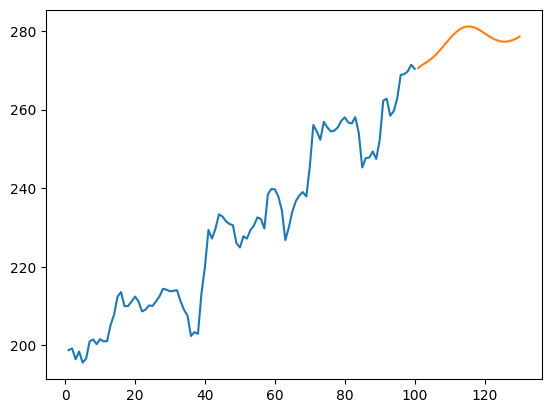

In [68]:
plt.plot(day_new,scaler.inverse_transform(df1[1367:]))
plt.plot(day_pred,scaler.inverse_transform(lst_output))

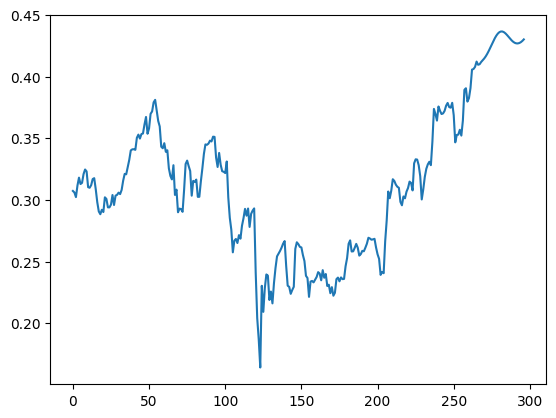

In [69]:
df3=df1.tolist()
df3.extend(lst_output)
plt.plot(df3[1200:])

In [70]:
df3=scaler.inverse_transform(df3).tolist()

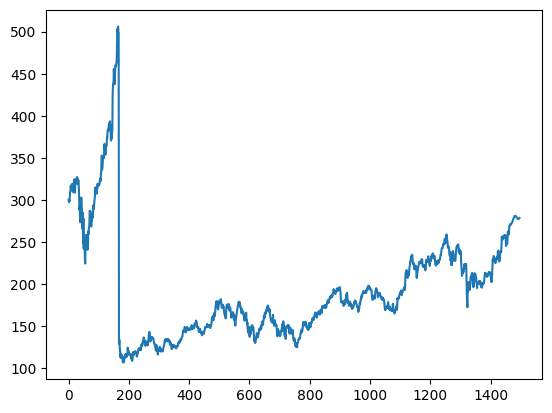

In [71]:
plt.plot(df3)

In [72]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
import numpy as np

# Actual values
y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(ytest.reshape(-1,1))

# RMSE
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predict))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predict))

# MAE
train_mae = mean_absolute_error(y_train_actual, train_predict)
test_mae = mean_absolute_error(y_test_actual, test_predict)

# MAPE
train_mape = np.mean(
    np.abs((y_train_actual-train_predict)/y_train_actual)
)*100

test_mape = np.mean(
    np.abs((y_test_actual-test_predict)/y_test_actual)
)*100

# R2
train_r2 = r2_score(y_train_actual, train_predict)
test_r2 = r2_score(y_test_actual, test_predict)

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

print("Train MAPE:", train_mape)
print("Test MAPE:", test_mape)

print("Train R2:", train_r2)
print("Test R2:", test_r2)

Train RMSE: 10.316225376464134
Test RMSE: 6.309410000070224
Train MAE: 4.370631643662432
Test MAE: 4.643316674036206
Train MAPE: 2.5901639436372097
Test MAPE: 2.155261792335982
Train R2: 0.9782539482880594
Test R2: 0.9286216175680004


In [73]:

model.save("lstm_stock_model.h5")

import joblib
joblib.dump(scaler, "scaler.pkl")



['scaler.pkl']